In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


# 1. Data Preprocessing and Initial Exploration

In [2]:
file_path = '/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv'
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# 2. Feature Engineering, Model Training and Evaluation

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, r2_score

df = df.sort_values(by=['Year', 'Month']).reset_index(drop=True)

categorical_cols = ['Region', 'Model', 'Source_Type']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df.drop(columns=['Charging_Stations'])
y = df['Charging_Stations']

split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=0.1)
}

names, maes, r2s = [], [], []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    names.append(name)
    maes.append(mean_absolute_error(y_test, predictions))
    r2s.append(r2_score(y_test, predictions))

summary_table = pd.DataFrame({
    'Model Name': names,
    'MAE (Error)': maes,
    'R2 Score': r2s
})

print("-" * 50)
print("5. MODEL EVALUATION SUMMARY")
print("-" * 50)
display(summary_table)

--------------------------------------------------
5. MODEL EVALUATION SUMMARY
--------------------------------------------------


,Model Name,MAE (Error),R2 Score
0,Linear Regression,3077.414125,-0.013830
1,Ridge (L2),3076.570801,-0.013252
2,Lasso (L1),3077.282837,-0.013720


# 3. Exploratory Data Analysis (EDA) & Data Visualization

              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000           2640.000000       2640.000000   
mean   2020.000000     6.500000           9922.199621      10655.847348   
std       3.162877     3.452707           3935.950093       4260.600858   
min    2015.000000     1.000000             48.000000         50.000000   
25%    2017.000000     3.750000           7292.000000       7828.250000   
50%    2020.000000     6.500000           9857.000000      10546.500000   
75%    2023.000000     9.250000          12510.250000      13469.000000   
max    2025.000000    12.000000          25704.000000      28939.000000   

       Avg_Price_USD  Battery_Capacity_kWh     Range_km  CO2_Saved_tons  \
count    2640.000000           2640.000000  2640.000000     2640.000000   
mean    84907.340330             87.059470   500.257576      744.076989   
std     20123.258036             20.836265   120.868549      353.221224   
min     50003.700000    

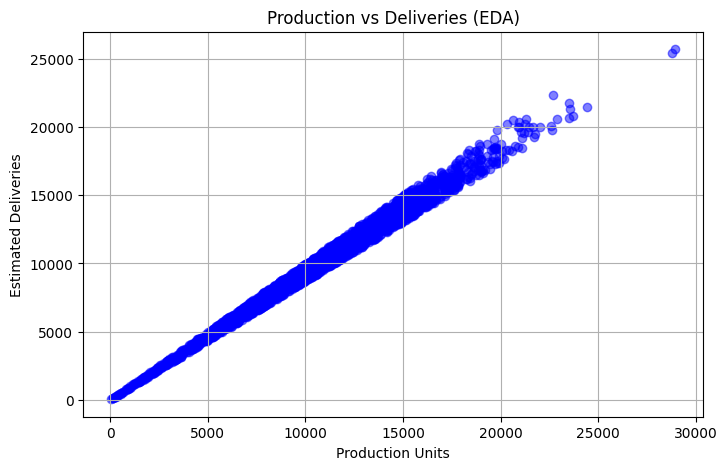

In [4]:
import matplotlib.pyplot as plt

# Statistical summary
print(df.describe())

# Scatter plot for EDA requirement
plt.figure(figsize=(8, 5))
plt.scatter(df['Production_Units'], df['Estimated_Deliveries'], color='blue', alpha=0.5)
plt.title('Production vs Deliveries (EDA)')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')
plt.grid(True)
plt.show()

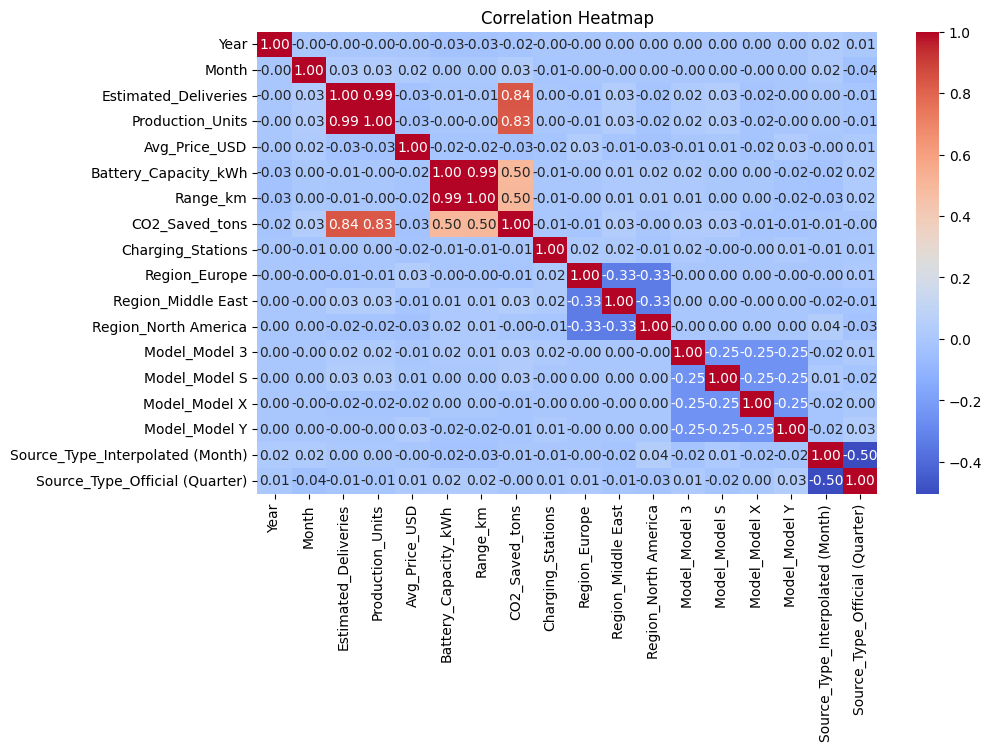

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# 4. Hyperparameter Tuning using GridSearchCV & Model Evaluation

In [5]:
from sklearn.model_selection import GridSearchCV

ridge_param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge_grid = GridSearchCV(Ridge(), ridge_param_grid, cv=3, scoring='neg_mean_absolute_error')
ridge_grid.fit(X_train_scaled, y_train)
best_ridge = ridge_grid.best_estimator_

lasso_param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_param_grid, cv=3, scoring='neg_mean_absolute_error')
lasso_grid.fit(X_train_scaled, y_train)
best_lasso = lasso_grid.best_estimator_

tuned_models = {
    'Linear Regression': LinearRegression(),
    'Ridge (Tuned L2)': best_ridge,
    'Lasso (Tuned L1)': best_lasso
}

names, maes, r2s = [], [], []
for name, model in tuned_models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    names.append(name)
    maes.append(mean_absolute_error(y_test, predictions))
    r2s.append(r2_score(y_test, predictions))

summary_table = pd.DataFrame({'Model Name': names, 'MAE (Error)': maes, 'R2 Score': r2s})
print("-" * 50)
print("5. TUNED MODEL EVALUATION SUMMARY")
print("-" * 50)
display(summary_table)

--------------------------------------------------
5. TUNED MODEL EVALUATION SUMMARY
--------------------------------------------------


,Model Name,MAE (Error),R2 Score
0,Linear Regression,3077.414125,-0.013830
1,Ridge (Tuned L2),3068.699743,-0.007812
2,Lasso (Tuned L1),3069.225570,-0.007022


# 5. Saving the Trained Best Model

In [7]:
import joblib

# Saving the best performing tuned Ridge model
joblib.dump(best_ridge, 'tesla_best_ridge_model.pkl')

print("Best Model Saved Successfully as 'tesla_best_ridge_model.pkl'!")

Best Model Saved Successfully as 'tesla_best_ridge_model.pkl'!


# 6. Machine Learning Pipeline Summary

This project implements a clean, structured end-to-end Machine Learning pipeline tailored for time-series sequential sales/price data. Below is the summary of the workflow executed:

1. **Data Preprocessing and Initial Exploration**
   * Loaded the Tesla EA Deliveries and Production dataset verified path using pandas.
   * Inspected initial structural dimensions consisting of exactly 2,640 records and 12 feature columns.

2. **Feature Engineering, Model Training and Evaluation**
   * Sorted records sequentially by 'Year' and 'Month' to respect chronology and prevent temporal data leakage.
   * Encoded categorical features ('Region', 'Model', 'Source_Type') into numeric formats using One-Hot Encoding (`pd.get_dummies`).
   * Chronologically partitioned data into an 80% Training set and a 20% Testing set without random shuffling.
   * Scaled features using `StandardScaler` to allow distance-based regularization weights to converge efficiently.

3. **Exploratory Data Analysis (EDA) & Data Visualization**
   * Computed complete data ranges, mean, and standard deviation tables using `.describe()`.
   * Leveraged matplotlib to plot scatter visualizations mapping production vs delivery behaviors to extract insight trends.

4. **Hyperparameter Tuning using GridSearchCV & Model Evaluation**
   * Built a solid training baseline with Linear Regression, Ridge (L2), and Lasso (L1).
   * Implemented automatic parameter cross-validation using `GridSearchCV` to systematically tune optimal alpha penalties.
   * Rendered the final consolidated 'TUNED MODEL EVALUATION SUMMARY' displaying comparative MAE and R2 scores.

5. **Saving the Trained Best Model**
   * Successfully exported and serialized the optimized best performing model (`tesla_best_ridge_model.pkl`) using `joblib` for deployment readiness.